Addition of 23 + 45 -> 68

Subtraction of 123 - 45 -> 78

Multiplication of 2 * 5 -> 10

divition of 1123 / 45 -> 24.955555555555556

Modulus of 2311 % 45 -> 16

unknown operation



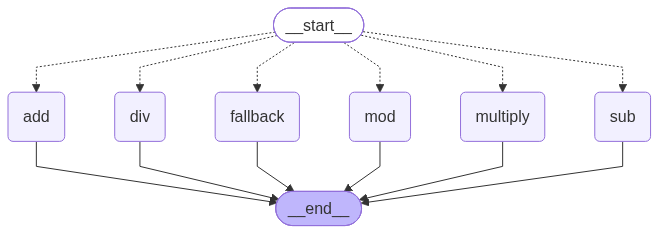

In [2]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display
class CalcState(TypedDict):
    task_type: str
    input1 : str
    input2 : str
    output : str
    
def dispatcher(state) -> Literal["add","sub","multi","div","mod"]:
    task = state["task_type"].lower().strip()
    if(task == "add"):
        return "add"
    elif(task == "sub"):
        return "sub"
    elif(task == "multiply"):
        return "multiply"
    elif(task == "div"):
        return "div"
    elif(task == "mod"):
        return "mod"
    else:
        return "fallback"
    
def add_task(state):
    output = state["input1"] + state["input2"]
    print(f"Addition of {state["input1"]} + {state["input2"]} -> {output}")
    return {
        "output" : output
    }
    
def sub_task(state):
    output = state["input1"] - state["input2"]
    print(f"Subtraction of {state["input1"]} - {state["input2"]} -> {output}")
    return {
        "output" : output
    }
    
def multiply_task(state):
    output = state["input1"] * state["input2"]
    print(f"Multiplication of {state["input1"]} * {state["input2"]} -> {output}")
    return {
        "output" : output
    }
    
def div_task(state):
    output = state["input1"] / state["input2"]
    print(f"divition of {state["input1"]} / {state["input2"]} -> {output}")
    return {
        "output" : output
    }
    
def mod_task(state):
    output = state["input1"] % state["input2"]
    print(f"Modulus of {state["input1"]} % {state["input2"]} -> {output}")
    return {
        "output" : output
    }
    
def fallback(state):
    output = f"unknown operation"
    print(f"{output}")
    return {
        "output" : output
    }
    
builder = StateGraph(CalcState)
builder.add_node("add",add_task)
builder.add_node("sub",sub_task)
builder.add_node("multiply",multiply_task)
builder.add_node("div",div_task)
builder.add_node("mod",mod_task)
builder.add_node("fallback",fallback)

builder.add_conditional_edges(
    START,
    dispatcher,
    {
        "add" : "add",
        "sub" : "sub",
        "multiply" : "multiply",
        "div" : "div",
        "mod" : "mod",
        "fallback" : "fallback"
    }
)
builder.add_edge("add",END)
builder.add_edge("sub",END)
builder.add_edge("multiply",END)
builder.add_edge("div",END)
builder.add_edge("mod",END)
builder.add_edge("fallback",END)

graph = builder.compile()

tasks = [
    {"task_type":"add","input1" : 23,"input2" : 45,"output":""},
    {"task_type":"sub","input1" : 123,"input2" : 45,"output":""},
    {"task_type":"multiply","input1" : 2,"input2" : 5,"output":""},
    {"task_type":"div","input1" : 1123,"input2" : 45,"output":""},
    {"task_type":"mod","input1" : 2311,"input2" : 45,"output":""},
    {"task_type":"unknown","input1" : 23,"input2" : 45,"output":""}
]

for task in tasks:
    result = graph.invoke(task)
    print()
    
display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)